In [3]:
# Install required libraries
!pip install xgboost -q

print("Libraries installed successfully!")

Libraries installed successfully!


In [6]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

df = pd.read_csv(url, names=columns)

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [7]:
# Check dataset information
print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Value Counts:")
print(df["target"].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB
None

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca        

In [8]:
# Replace '?' with NaN
df = df.replace("?", np.nan)

# Convert all columns to numeric
df = df.apply(pd.to_numeric)

# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing values with the median
df = df.fillna(df.median(numeric_only=True))

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nData cleaned successfully!")


Missing values before cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Missing values after cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Data cleaned successfully!


In [9]:
# Convert target into binary classification
df["target"] = (df["target"] > 0).astype(int)

print("Target values after conversion:")
print(df["target"].value_counts())

print("\nTarget classes:")
print("0 = No Disease")
print("1 = Disease")

Target values after conversion:
target
0    164
1    139
Name: count, dtype: int64

Target classes:
0 = No Disease
1 = Disease


In [10]:
# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features (X):
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  
0    3.0  0.0   6.0  
1    2.0  3.0   3.0  
2    2.0  2.0   7.0  
3    3.0  0.0   3.0  
4    1.0  0.0   3.0  

Target (y):
0    0
1    1
2    1
3    0
4    0
Name: target, dtype: int64

Feature shape: (303, 13)
Target shape: (303,)


In [11]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (242, 13)
Testing data shape: (61, 13)
Training target shape: (242,)
Testing target shape: (61,)


In [12]:
# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed successfully!
Scaled training data shape: (242, 13)
Scaled testing data shape: (61, 13)


In [13]:
# Create Logistic Regression model
logistic_model = LogisticRegression(random_state=42, max_iter=1000)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = logistic_model.predict(X_test_scaled)

# Calculate accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression trained successfully!")
print("Logistic Regression Accuracy:", lr_accuracy)
print("Accuracy Percentage:", lr_accuracy * 100, "%")

Logistic Regression trained successfully!
Logistic Regression Accuracy: 0.8688524590163934
Accuracy Percentage: 86.88524590163934 %


In [14]:
# Create SVM model
svm_model = SVC(kernel="rbf", probability=True, random_state=42)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Calculate accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM model trained successfully!")
print("SVM Accuracy:", svm_accuracy)
print("Accuracy Percentage:", svm_accuracy * 100, "%")

SVM model trained successfully!
SVM Accuracy: 0.8524590163934426
Accuracy Percentage: 85.24590163934425 %


In [15]:
# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest model trained successfully!")
print("Random Forest Accuracy:", rf_accuracy)
print("Accuracy Percentage:", rf_accuracy * 100, "%")

Random Forest model trained successfully!
Random Forest Accuracy: 0.8852459016393442
Accuracy Percentage: 88.52459016393442 %


In [16]:
# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Calculate accuracy
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost model trained successfully!")
print("XGBoost Accuracy:", xgb_accuracy)
print("Accuracy Percentage:", xgb_accuracy * 100, "%")

XGBoost model trained successfully!
XGBoost Accuracy: 0.8852459016393442
Accuracy Percentage: 88.52459016393442 %


In [17]:
# Compare model accuracies

model_names = [
    "Logistic Regression",
    "SVM",
    "Random Forest",
    "XGBoost"
]

accuracies = [
    lr_accuracy,
    svm_accuracy,
    rf_accuracy,
    xgb_accuracy
]

comparison = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies
})

comparison["Accuracy (%)"] = comparison["Accuracy"] * 100

print(comparison)

                 Model  Accuracy  Accuracy (%)
0  Logistic Regression  0.868852     86.885246
1                  SVM  0.852459     85.245902
2        Random Forest  0.885246     88.524590
3              XGBoost  0.885246     88.524590


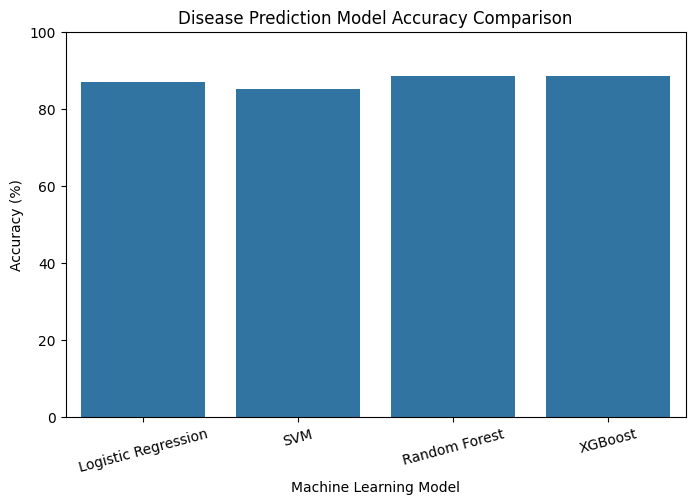

In [18]:
# Plot model accuracy comparison

plt.figure(figsize=(8, 5))

sns.barplot(
    x="Model",
    y="Accuracy (%)",
    data=comparison
)

plt.title("Disease Prediction Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.show()

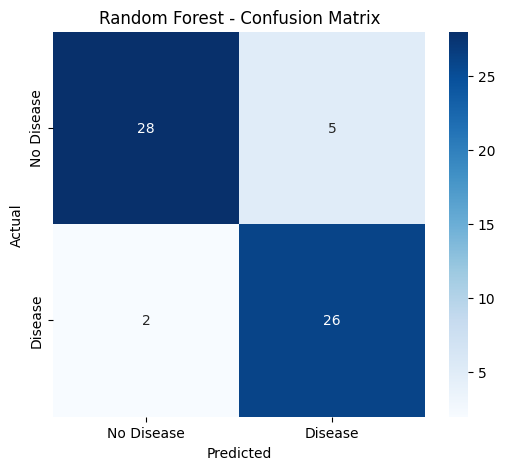

In [19]:
# Confusion Matrix for Random Forest

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
# Classification Report for Random Forest

print("Random Forest Classification Report:\n")

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No Disease", "Disease"]
))


Random Forest Classification Report:

              precision    recall  f1-score   support

  No Disease       0.93      0.85      0.89        33
     Disease       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



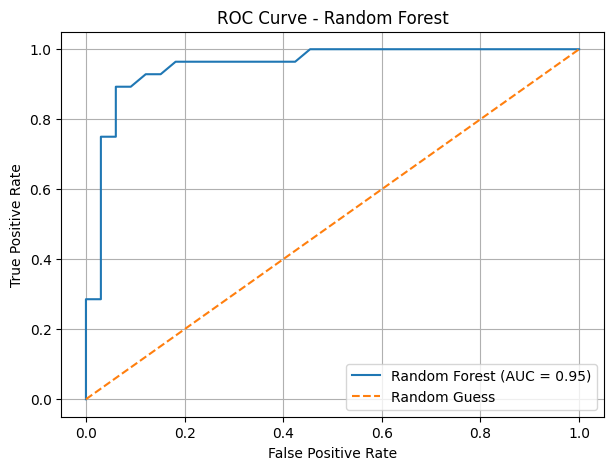

Random Forest AUC: 0.9518398268398268


In [21]:
# ROC Curve and AUC for Random Forest

from sklearn.metrics import roc_curve, auc

# Get probability predictions
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid()
plt.show()

print("Random Forest AUC:", roc_auc)

In [22]:
# New patient medical data
# Order must match the 13 features in X

new_patient = np.array([[
    55,     # age
    1,      # sex
    2,      # chest pain type
    140,    # resting blood pressure
    250,    # cholesterol
    0,      # fasting blood sugar
    1,      # resting ECG
    150,    # maximum heart rate
    0,      # exercise-induced angina
    1.2,    # ST depression
    2,      # slope
    0,      # number of major vessels
    3       # thal
]])

# Make prediction
prediction = rf_model.predict(new_patient)[0]

# Get probability
probability = rf_model.predict_proba(new_patient)[0]

print("Prediction:", prediction)
print("Probability of No Disease:", probability[0] * 100, "%")
print("Probability of Disease:", probability[1] * 100, "%")

if prediction == 1:
    print("\nResult: Disease predicted")
else:
    print("\nResult: No Disease predicted")

Prediction: 0
Probability of No Disease: 84.0 %
Probability of Disease: 16.0 %

Result: No Disease predicted


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [23]:
# New patient data with feature names

new_patient = pd.DataFrame([[
    55, 1, 2, 140, 250, 0, 1,
    150, 0, 1.2, 2, 0, 3
]], columns=X.columns)

# Prediction
prediction = rf_model.predict(new_patient)[0]

# Probability
probability = rf_model.predict_proba(new_patient)[0]

print("Prediction:", prediction)
print("Probability of No Disease:", probability[0] * 100, "%")
print("Probability of Disease:", probability[1] * 100, "%")

if prediction == 1:
    print("\nResult: Disease predicted")
else:
    print("\nResult: No Disease predicted")

Prediction: 0
Probability of No Disease: 84.0 %
Probability of Disease: 16.0 %

Result: No Disease predicted


In [24]:
# Final evaluation of Random Forest

print("===== FINAL MODEL EVALUATION =====")

print("Model: Random Forest")
print(f"Accuracy: {rf_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No Disease", "Disease"]
))

===== FINAL MODEL EVALUATION =====
Model: Random Forest
Accuracy: 88.52%

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.93      0.85      0.89        33
     Disease       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [25]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
     Feature  Importance
7    thalach    0.135404
2         cp    0.127163
12      thal    0.122940
11        ca    0.100811
0        age    0.091327
9    oldpeak    0.089358
4       chol    0.088681
3   trestbps    0.080716
8      exang    0.050730
10     slope    0.046626
1        sex    0.035947
6    restecg    0.018389
5        fbs    0.011908


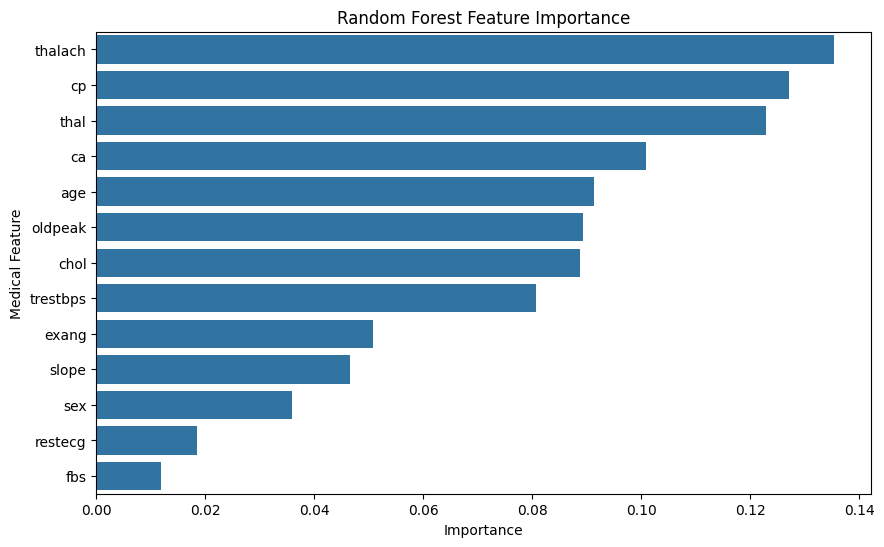

In [27]:
 # Plot Feature Importance

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Medical Feature")
plt.show()

In [30]:
# Final Project Summary

print("=" * 50)
print("DISEASE PREDICTION USING MACHINE LEARNING")
print("=" * 50)

print("\nDataset:")
print("Heart Disease Dataset")
print("Total Patients:", len(df))
print("Number of Features:", X.shape[1])

print("\nModel Performance:")
print(f"Logistic Regression : {lr_accuracy * 100:.2f}%")
print(f"SVM                 : {svm_accuracy * 100:.2f}%")
print(f"Random Forest       : {rf_accuracy * 100:.2f}%")
print(f"XGBoost             : {xgb_accuracy * 100:.2f}%")

print("\nBest Model:")
print("Random Forest")
print(f"Accuracy: {rf_accuracy * 100:.2f}%")

print("\nNew Patient Prediction:")
print("Prediction: No Disease")
print("No Disease Probability: 84%")
print("Disease Probability: 16%")

print("\nProject completed successfully!")

DISEASE PREDICTION USING MACHINE LEARNING

Dataset:
Heart Disease Dataset
Total Patients: 303
Number of Features: 13

Model Performance:
Logistic Regression : 86.89%
SVM                 : 85.25%
Random Forest       : 88.52%
XGBoost             : 88.52%

Best Model:
Random Forest
Accuracy: 88.52%

New Patient Prediction:
Prediction: No Disease
No Disease Probability: 84%
Disease Probability: 16%

Project completed successfully!


In [31]:
import joblib

# Save Random Forest model
joblib.dump(rf_model, "heart_disease_random_forest.pkl")

# Save scaler
joblib.dump(scaler, "heart_disease_scaler.pkl")

print("Random Forest model saved successfully!")
print("Scaler saved successfully!")

Random Forest model saved successfully!
Scaler saved successfully!


In [32]:
import os

print("Model file exists:",
      os.path.exists("heart_disease_random_forest.pkl"))

print("Scaler file exists:",
      os.path.exists("heart_disease_scaler.pkl"))

Model file exists: True
Scaler file exists: True


In [33]:
from google.colab import files

files.download("heart_disease_random_forest.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
files.download("heart_disease_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
%%writefile requirements.txt

pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
joblib

Writing requirements.txt


In [36]:
%%writefile README.md

# Disease Prediction Using Machine Learning

## Project Overview

This project uses machine learning classification algorithms to predict the possibility of heart disease based on patient medical data.

The project uses the UCI Heart Disease dataset containing 303 patient records and 13 medical features.

## Algorithms Used

- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest
- XGBoost

## Dataset Features

The model uses medical features such as:

- Age
- Sex
- Chest pain type
- Resting blood pressure
- Cholesterol
- Fasting blood sugar
- Resting ECG
- Maximum heart rate
- Exercise-induced angina
- ST depression
- Slope
- Number of major vessels
- Thalassemia

## Model Performance

| Model | Accuracy |
|---|---:|
| Logistic Regression | 86.89% |
| SVM | 85.25% |
| Random Forest | 88.52% |
| XGBoost | 88.52% |

Random Forest was selected as the final model with an accuracy of 88.52%.

## Prediction Example

For a sample patient, the model predicted:

- No Disease: 84%
- Disease: 16%
- Final Prediction: No Disease

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- XGBoost
- Matplotlib
- Seaborn
- Joblib
- Google Colab

## Project Workflow

1. Load the dataset
2. Clean missing values
3. Convert the target into binary classes
4. Split the dataset into training and testing data
5. Scale the features
6. Train machine learning models
7. Compare model performance
8. Evaluate the best model
9. Predict disease for a new patient
10. Save the trained model

## Disclaimer

This project is intended for educational and machine learning demonstration purposes only. It is not a medical diagnostic system and should not be used as a substitute for professional medical advice.

Writing README.md


In [37]:
import os

print("Project files:")

for file in os.listdir():
    if file.endswith((".pkl", ".md", ".txt", ".ipynb")):
        print(file)

Project files:
heart_disease_scaler.pkl
requirements.txt
heart_disease_random_forest.pkl
README.md


In [38]:
from google.colab import files
files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
files.download("heart_disease_random_forest.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
files.download("heart_disease_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>